# Airport reference table

Exploration of the BTS *Master Coordinate* table (`T_MASTER_CORD`), which supplies the
coordinates used to attach weather to each flight.

Questions addressed here:

1. What does the table contain, and at what granularity?
2. How many rows per airport, and why more than one?
3. Which filters reduce it to a usable reference?
4. Does it cover every airport appearing in the flight data?
5. Where do timezones come from?

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from timezonefinder import TimezoneFinder

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

RAW_DIR = Path("../data/external/raw")
cord = pd.read_csv(RAW_DIR / "T_MASTER_CORD.csv")
print(f"{len(cord):,} rows, {cord.shape[1]} columns")

20,282 rows, 28 columns


## 1. Contents

In [2]:
print(cord.columns.tolist())
cord.head(3)

['AIRPORT_SEQ_ID', 'AIRPORT_ID', 'AIRPORT', 'DISPLAY_AIRPORT_NAME', 'DISPLAY_AIRPORT_CITY_NAME_FULL', 'AIRPORT_WAC', 'AIRPORT_COUNTRY_NAME', 'AIRPORT_COUNTRY_CODE_ISO', 'AIRPORT_STATE_NAME', 'AIRPORT_STATE_CODE', 'AIRPORT_STATE_FIPS', 'CITY_MARKET_ID', 'DISPLAY_CITY_MARKET_NAME_FULL', 'CITY_MARKET_WAC', 'LAT_DEGREES', 'LAT_HEMISPHERE', 'LAT_MINUTES', 'LAT_SECONDS', 'LATITUDE', 'LON_DEGREES', 'LON_HEMISPHERE', 'LON_MINUTES', 'LON_SECONDS', 'LONGITUDE', 'AIRPORT_START_DATE', 'AIRPORT_THRU_DATE', 'AIRPORT_IS_CLOSED', 'AIRPORT_IS_LATEST']


,AIRPORT_SEQ_ID,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,DISPLAY_AIRPORT_CITY_NAME_FULL,AIRPORT_WAC,AIRPORT_COUNTRY_NAME,AIRPORT_COUNTRY_CODE_ISO,AIRPORT_STATE_NAME,AIRPORT_STATE_CODE,AIRPORT_STATE_FIPS,CITY_MARKET_ID,DISPLAY_CITY_MARKET_NAME_FULL,CITY_MARKET_WAC,LAT_DEGREES,LAT_HEMISPHERE,LAT_MINUTES,LAT_SECONDS,LATITUDE,LON_DEGREES,LON_HEMISPHERE,LON_MINUTES,LON_SECONDS,LONGITUDE,AIRPORT_START_DATE,AIRPORT_THRU_DATE,AIRPORT_IS_CLOSED,AIRPORT_IS_LATEST
0,1000101,10001,01A,Afognak Lake Airport,"Afognak Lake, AK",1,United States,US,Alaska,AK,2.0,30001,"Afognak Lake, AK",1,58.0,N,6.0,34.0,58.109444,152.0,W,54.0,24.0,-152.906667,7/1/2007 12:00:00 AM,NaN,0,1
1,1000301,10003,03A,Bear Creek Mining Strip,"Granite Mountain, AK",1,United States,US,Alaska,AK,2.0,30003,"Granite Mountain, AK",1,65.0,N,32.0,53.0,65.548056,161.0,W,4.0,18.0,-161.071667,7/1/2007 12:00:00 AM,NaN,0,1
2,1000401,10004,04A,Lik Mining Camp,"Lik, AK",1,United States,US,Alaska,AK,2.0,30004,"Lik, AK",1,68.0,N,5.0,0.0,68.083333,163.0,W,10.0,0.0,-163.166667,7/1/2007 12:00:00 AM,NaN,0,1


In [3]:
# Three identifiers coexist, at different levels of stability.
for col in ["AIRPORT_SEQ_ID", "AIRPORT_ID", "AIRPORT"]:
    print(f"{col:16} {cord[col].nunique():,} distinct values")

AIRPORT_SEQ_ID   20,282 distinct values
AIRPORT_ID       6,902 distinct values
AIRPORT          6,928 distinct values


`AIRPORT` is the three-letter code printed on tickets. BTS documents it as reusable:
a code released by one airport can later be assigned to another. `AIRPORT_ID` is a
numeric key that stays with the airport, and `AIRPORT_SEQ_ID` identifies one airport at
one point in time.

The flight data carries both `Origin` (the letter code) and `OriginAirportID` (the stable key), so the
join can use the stable key while keeping the readable one as a label.

## 2. Multiple rows per airport

The table is historical: attributes that changed over time produce one row per period.

In [4]:
rows_per_airport = cord["AIRPORT_ID"].value_counts()
print(rows_per_airport.describe())
print(f"\nairports with more than one row: {(rows_per_airport > 1).sum():,}")

count    6902.000000
mean        2.938569
std         1.883429
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        12.000000
Name: count, dtype: float64

airports with more than one row: 5,033


In [5]:
# What changes between rows of the same airport.
repeated = rows_per_airport[rows_per_airport > 1].index[:3]
cols = [
    "AIRPORT_ID", "AIRPORT", "DISPLAY_AIRPORT_NAME",
    "LATITUDE", "LONGITUDE",
    "AIRPORT_START_DATE", "AIRPORT_THRU_DATE", "AIRPORT_IS_LATEST",
]
cord[cord["AIRPORT_ID"].isin(repeated)][cols].sort_values(["AIRPORT_ID", "AIRPORT_START_DATE"])

,AIRPORT_ID,AIRPORT,DISPLAY_AIRPORT_NAME,LATITUDE,LONGITUDE,AIRPORT_START_DATE,AIRPORT_THRU_DATE,AIRPORT_IS_LATEST
5768,11881,GDX,Sokol,59.910000,150.716667,1/1/1992 12:00:00 AM,6/30/2011 12:00:00 AM,0
5778,11881,GDX,Sokol,59.910833,150.720278,10/1/2022 12:00:00 AM,NaN,1
5770,11881,GDX,Sokol,59.911111,150.720556,11/1/2011 12:00:00 AM,7/31/2012 12:00:00 AM,0
5776,11881,GDX,Sokol,59.910833,150.720278,11/1/2017 12:00:00 AM,11/30/2017 12:00:00 AM,0
5777,11881,GDX,Magadan Airport,59.910833,150.720278,12/1/2017 12:00:00 AM,9/30/2022 12:00:00 AM,0
5767,11881,GDX,Sokol,59.910000,150.716667,3/1/1991 12:00:00 AM,12/31/1991 12:00:00 AM,0
5772,11881,GDX,Magadan Airport,59.911111,150.725000,5/1/2015 12:00:00 AM,5/31/2015 12:00:00 AM,0
5773,11881,GDX,Magadan Sokol,59.911111,150.725000,6/1/2015 12:00:00 AM,7/31/2015 12:00:00 AM,0
5769,11881,GDX,Sokol,59.910833,150.720278,7/1/2011 12:00:00 AM,10/31/2011 12:00:00 AM,0
5771,11881,GDX,Sokol,59.911111,150.725000,8/1/2012 12:00:00 AM,4/30/2015 12:00:00 AM,0


## 3. Filters

Three filters reduce the table to one usable row per airport.

In [6]:
steps = [("raw", len(cord))]

us = cord[cord["AIRPORT_COUNTRY_CODE_ISO"] == "US"]
steps.append(("US only", len(us)))

latest = us[us["AIRPORT_IS_LATEST"] == 1]
steps.append(("current record", len(latest)))

open_airports = latest[latest["AIRPORT_IS_CLOSED"] != 1]
steps.append(("not closed", len(open_airports)))

with_coords = open_airports.dropna(subset=["LATITUDE", "LONGITUDE"])
steps.append(("with coordinates", len(with_coords)))

for label, n in steps:
    print(f"{label:18} {n:>7,}")

raw                 20,282
US only              7,726
current record       2,974
not closed           2,829
with coordinates     2,828


In [7]:
# AIRPORT_IS_LATEST is what makes the deduplication correct: without it, keeping the
# first row per airport could retain superseded coordinates.
print(f"duplicate AIRPORT_ID after filtering: {with_coords['AIRPORT_ID'].duplicated().sum()}")

duplicate AIRPORT_ID after filtering: 0


## 4. Coverage of the flight data

An airport present in the flights but missing here cannot be matched to a weather
location, so its flights lose their weather features.

In [9]:
RAW_DIR = Path("../data/raw")
csv_paths = sorted(RAW_DIR.rglob("*.csv"))[:12]

flights = pd.concat(
    [pd.read_csv(p, usecols=["OriginAirportID", "DestAirportID"]) for p in csv_paths],
    ignore_index=True,
)

used = set(flights["OriginAirportID"].dropna()) | set(flights["DestAirportID"].dropna())
covered = set(with_coords["AIRPORT_ID"].dropna())

print(f"airports in the flight data: {len(used):,}")
print(f"airports in the reference:   {len(covered):,}")
print(f"missing from the reference:  {sorted(used - covered)}")

airports in the flight data: 352
airports in the reference:   2,828
missing from the reference:  []


The reference is far larger than what the flights require: it lists every airport under
BTS jurisdiction, including private strips.

## 5. Timezones

BTS times are local to each airport; weather is stored in UTC. Converting between them
requires knowing each airport's timezone.

A fixed offset is not sufficient. New York is UTC-5 in winter and UTC-4 in summer, so an
offset applied uniformly would be wrong for roughly half the year.

The IANA zone name carries the transition rules with it, and is derived from the
coordinates instead.

In [10]:
tf = TimezoneFinder()
sample = with_coords.sample(min(2000, len(with_coords)), random_state=42).copy()
sample["TIMEZONE"] = sample.apply(
    lambda r: tf.timezone_at(lat=r["LATITUDE"], lng=r["LONGITUDE"]), axis=1
)

print(sample["TIMEZONE"].value_counts().head(15))
print(f"\nno timezone resolved: {sample['TIMEZONE'].isna().sum()}")

TIMEZONE
America/New_York                526
America/Chicago                 481
America/Anchorage               281
America/Los_Angeles             251
America/Denver                  136
America/Nome                     65
America/Sitka                    57
America/Detroit                  40
America/Phoenix                  38
America/Juneau                   29
America/Indiana/Indianapolis     22
America/Boise                    18
Pacific/Honolulu                 16
America/Puerto_Rico              12
America/St_Thomas                 5
Name: count, dtype: int64

no timezone resolved: 0


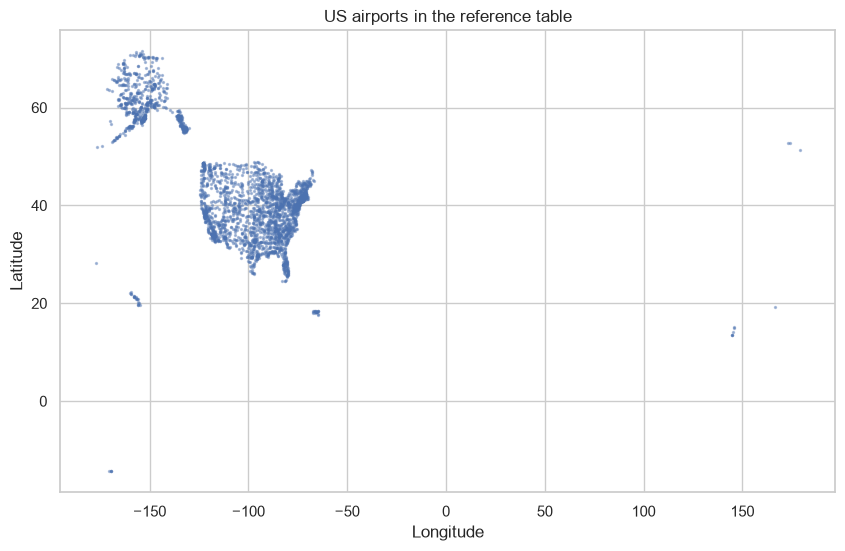

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(with_coords["LONGITUDE"], with_coords["LATITUDE"], s=2, alpha=0.4)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("US airports in the reference table")
plt.show()

## Implications

- **Join on `AIRPORT_ID`**, not on the three-letter code, which BTS documents as
  reusable. The flight data carries both.
- **Filter on `AIRPORT_IS_LATEST`**.
- **Keep every US airport**, not only those seen in the training months: the table also
  serves inference.
- **Derive the timezone from coordinates**.